In [6]:
import mne
import numpy as np
import matplotlib.pyplot as plt

file_path = r"E:\aditi_eeg\auditory_eeg\a5_auditory_2026-04-07_11-36-25_Segment_0.edf"

raw = mne.io.read_raw_edf(file_path, preload=True)

# Rename
raw.rename_channels(lambda x: x.replace('EEG ', '').replace('-CPz', ''))

# EOG
if 'EOG' in raw.ch_names:
    raw.set_channel_types({'EOG': 'eog'})

# Montage
raw.set_montage('standard_1020', on_missing='ignore')

# Filter
raw.filter(0.1, 30)
raw.notch_filter(50)

# Reference
raw.set_eeg_reference('average')

print("Channels:", raw.ch_names)

Extracting EDF parameters from E:\aditi_eeg\auditory_eeg\a5_auditory_2026-04-07_11-36-25_Segment_0.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 399359  =      0.000 ...   389.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 33793 samples (33.001 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6759 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Channels: ['FC5', 'FC1', 'FC2', 'FC6', 'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6', 'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'O2', 'EOG', 'AF7', 'AF3', 'AF4', 'AF8', 'F5', 'F1', 'F2', 'F6', 'FC3', 'FCz', 'FC4', 'C5', 'C1', 'C2', 'C6', 'CP3', 'CP4', 'P5', 'P1', 'P2', 'P6', 'PO5', 'PO3', 'PO4', 'PO6', 'FT7', 'FT8', 'TP7', 'TP8', 'PO7', 'PO8', 'Oz']


Using matplotlib as 2D backend.


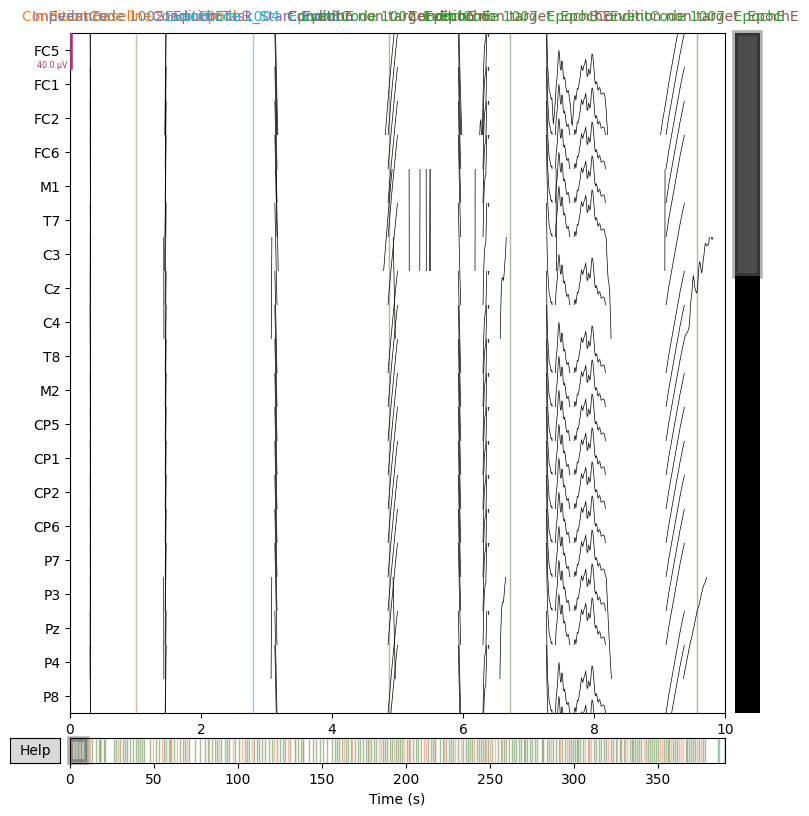

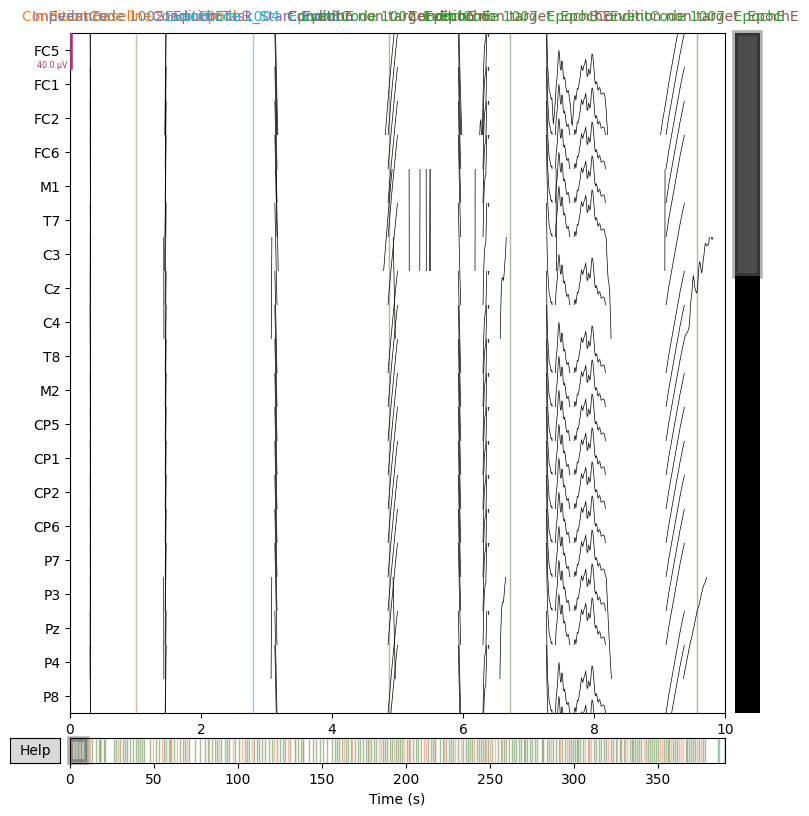

In [7]:
raw.plot(duration=10, n_channels=20, title="Raw EEG")

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 2.000 (s)
Plotting power spectral density (dB=True).


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


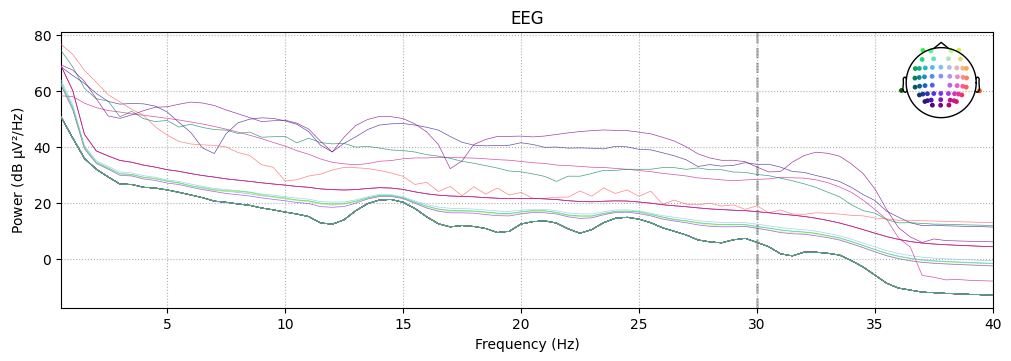

In [8]:
raw.plot_psd(fmin=0.5, fmax=40)

In [9]:
events, event_id = mne.events_from_annotations(raw)

print("Event IDs:", event_id)

Used Annotations descriptions: ['Condition Baseline End  EpochE', 'Condition Baseline Start  EpochE', 'Condition Task_End  EpochE', 'Condition Task_Start  EpochE', 'Condition non target  EpochE', 'Condition target  EpochE', 'EventCode 1002  EpochE', 'EventCode 1003  EpochE', 'EventCode 1004  EpochE', 'EventCode 1005  EpochE', 'EventCode 1006  EpochE', 'EventCode 1007  EpochE', 'Impedance']
Event IDs: {'Condition Baseline End  EpochE': 1, 'Condition Baseline Start  EpochE': 2, 'Condition Task_End  EpochE': 3, 'Condition Task_Start  EpochE': 4, 'Condition non target  EpochE': 5, 'Condition target  EpochE': 6, 'EventCode 1002  EpochE': 7, 'EventCode 1003  EpochE': 8, 'EventCode 1004  EpochE': 9, 'EventCode 1005  EpochE': 10, 'EventCode 1006  EpochE': 11, 'EventCode 1007  EpochE': 12, 'Impedance': 13}


In [10]:
epochs = mne.Epochs(
    raw,
    events,
    event_id=event_id,
    tmin=-0.2,
    tmax=0.8,
    baseline=(None, 0),
    preload=True,
    event_repeated='merge'
)

epochs

Multiple event values for single event times found. Creating new event value to reflect simultaneous events.
Not setting metadata
266 matching events found
Setting baseline interval to [-0.2001953125, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 266 events and 1025 original time points ...
2 bad epochs dropped


<Epochs | 264 events (all good), -0.2 – 0.8 s (baseline -0.2 – 0 s), ~115.7 MB, data loaded,
 'Impedance': 0
 'Condition Baseline Start  EpochE/EventCode 1002  EpochE': 1
 'Condition Task_Start  EpochE/EventCode 1004  EpochE': 1
 'Condition non target  EpochE/EventCode 1007  EpochE': 204
 'Condition target  EpochE/EventCode 1006  EpochE': 56
 'Condition Task_End  EpochE/EventCode 1005  EpochE': 1
 'Condition Baseline End  EpochE/EventCode 1003  EpochE': 1>

In [11]:
target_key = [k for k in epochs.event_id.keys() if "target" in k.lower()][0]

target_epochs = epochs[target_key]

print("Using:", target_key)

Using: Condition non target  EpochE/EventCode 1007  EpochE


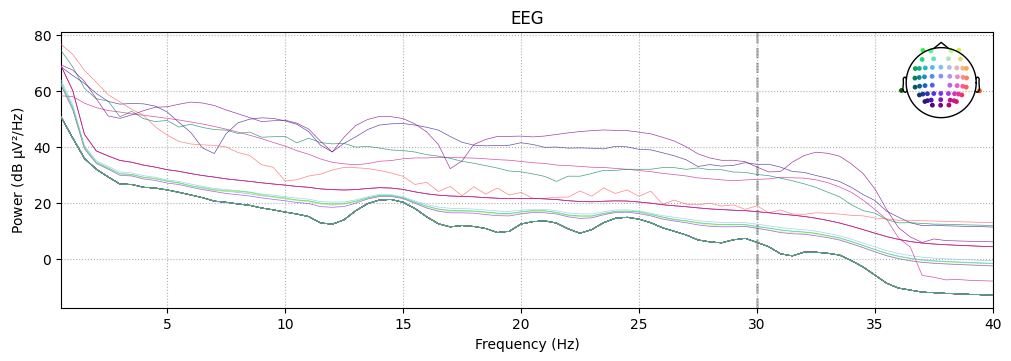

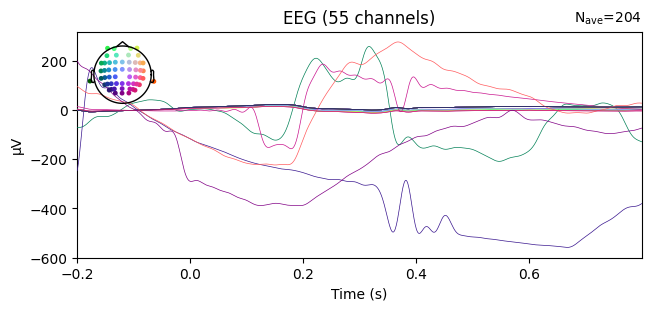

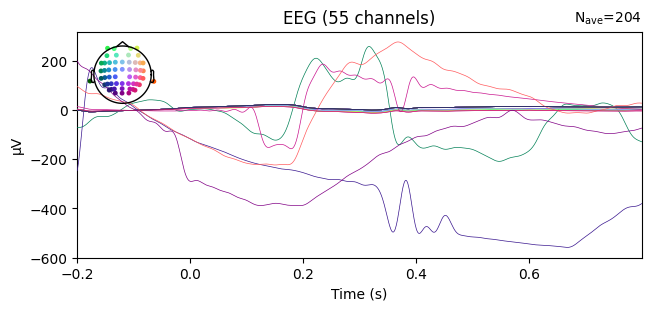

In [12]:
evoked = target_epochs.average()
evoked.plot()

Need more than one channel to make topography for eeg. Disabling interactivity.


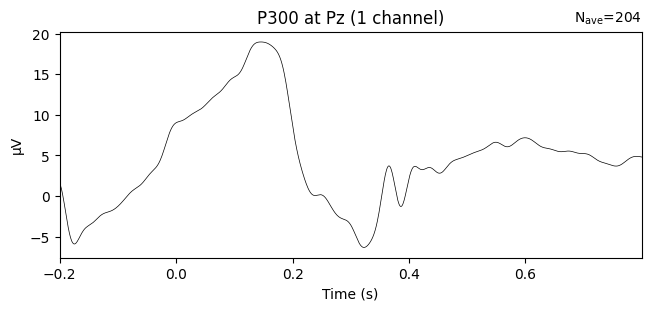

In [13]:
if 'Pz' in evoked.ch_names:
    evoked.plot(picks='Pz', titles="P300 at Pz")

In [14]:
data = target_epochs.get_data()
sfreq = target_epochs.info['sfreq']

amps = []
lats = []

for trial in data:
    signal = trial.mean(axis=0)
    amps.append(np.max(signal))
    lats.append(np.argmax(signal) / sfreq)

print("Avg Amplitude:", np.mean(amps))
print("Avg Latency:", np.mean(lats))

Avg Amplitude: 1.4445234581383667e-06
Avg Latency: 0.5109145220588235


In [17]:
raw.rename_channels(lambda x: x.replace('EEG ', '').replace('-CPz', ''))

<RawEDF | a5_auditory_2026-04-07_11-36-25_Segment_0.edf, 56 x 399360 (390.0 s), ~170.7 MB, data loaded>

In [18]:
raw.pick_types(eeg=True, eog=True)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


<RawEDF | a5_auditory_2026-04-07_11-36-25_Segment_0.edf, 56 x 399360 (390.0 s), ~170.7 MB, data loaded>

In [19]:
montage = mne.channels.make_standard_montage('standard_1020')

raw.set_montage(montage, on_missing='ignore')

<RawEDF | a5_auditory_2026-04-07_11-36-25_Segment_0.edf, 56 x 399360 (390.0 s), ~170.7 MB, data loaded>

In [20]:
print(raw.ch_names)

['FC5', 'FC1', 'FC2', 'FC6', 'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6', 'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'O2', 'EOG', 'AF7', 'AF3', 'AF4', 'AF8', 'F5', 'F1', 'F2', 'F6', 'FC3', 'FCz', 'FC4', 'C5', 'C1', 'C2', 'C6', 'CP3', 'CP4', 'P5', 'P1', 'P2', 'P6', 'PO5', 'PO3', 'PO4', 'PO6', 'FT7', 'FT8', 'TP7', 'TP8', 'PO7', 'PO8', 'Oz']


In [21]:
print(raw.get_montage())

<DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 55 channels>


In [22]:
events, event_id = mne.events_from_annotations(raw)

epochs = mne.Epochs(
    raw,
    events,
    event_id=event_id,
    tmin=-0.2,
    tmax=0.8,
    baseline=(None, 0),
    preload=True,
    event_repeated='merge'
)

target_key = [k for k in event_id.keys() if "target" in k.lower()][0]
evoked = epochs[target_key].average()

Used Annotations descriptions: ['Condition Baseline End  EpochE', 'Condition Baseline Start  EpochE', 'Condition Task_End  EpochE', 'Condition Task_Start  EpochE', 'Condition non target  EpochE', 'Condition target  EpochE', 'EventCode 1002  EpochE', 'EventCode 1003  EpochE', 'EventCode 1004  EpochE', 'EventCode 1005  EpochE', 'EventCode 1006  EpochE', 'EventCode 1007  EpochE', 'Impedance']
Multiple event values for single event times found. Creating new event value to reflect simultaneous events.
Not setting metadata
266 matching events found
Setting baseline interval to [-0.2001953125, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 266 events and 1025 original time points ...
2 bad epochs dropped


In [25]:
%matplotlib qt
evoked.plot_topomap(times=[0.3], ch_type='eeg')

import matplotlib.pyplot as plt
plt.title("P300 Topography")
plt.show()


In [24]:
evoked = evoked.copy().pick_types(eeg=True)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


In [26]:
raw.rename_channels(lambda x: x.replace('EEG ', '').replace('-CPz', ''))

<RawEDF | a5_auditory_2026-04-07_11-36-25_Segment_0.edf, 56 x 399360 (390.0 s), ~170.7 MB, data loaded>

In [27]:
raw.pick_types(eeg=True)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


<RawEDF | a5_auditory_2026-04-07_11-36-25_Segment_0.edf, 55 x 399360 (390.0 s), ~167.7 MB, data loaded>

In [28]:
import mne

montage = mne.channels.make_standard_montage('standard_1020')

raw.set_montage(montage, on_missing='ignore')

<RawEDF | a5_auditory_2026-04-07_11-36-25_Segment_0.edf, 55 x 399360 (390.0 s), ~167.7 MB, data loaded>

In [29]:
print(raw.get_montage())

<DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 55 channels>


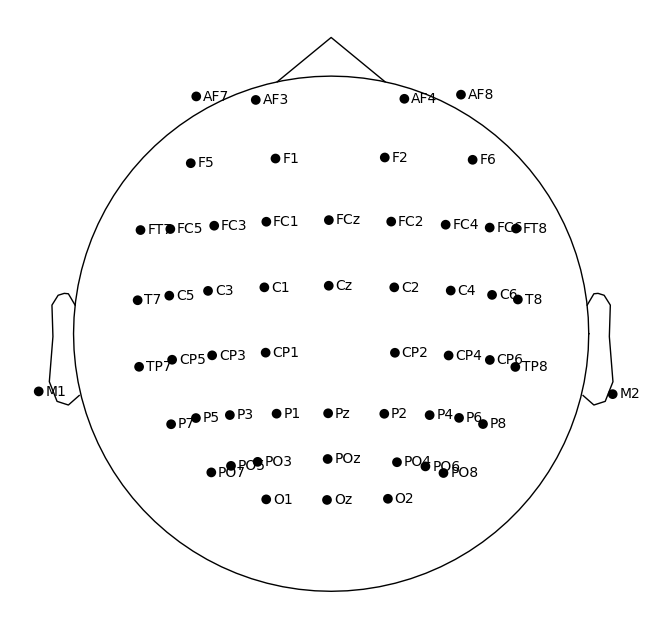

In [30]:
mne.viz.plot_sensors(raw.info, show_names=True)